In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report,
                             recall_score,
                             precision_score,
                             accuracy_score,
                             confusion_matrix)
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split, learning_curve,GridSearchCV

 


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


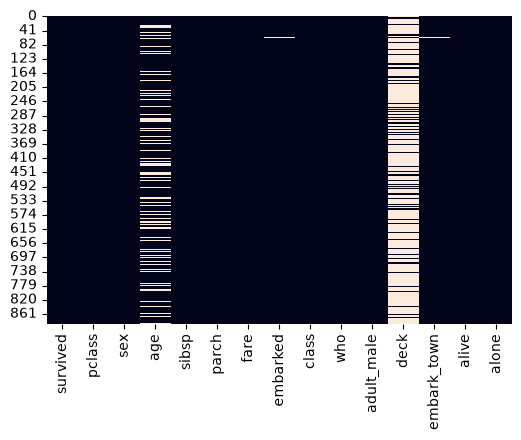

In [3]:
# Charger le dataset Titanic depuis seaborn
df = sns.load_dataset("titanic")

# Afficher les 5 premières lignes
display(df.head())


plt.figure(figsize=(6,4))
sns.heatmap(df.isna(),cbar=False)


plt.show()

In [4]:
df = df.drop(columns='deck')
df = df.dropna(subset='embarked')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


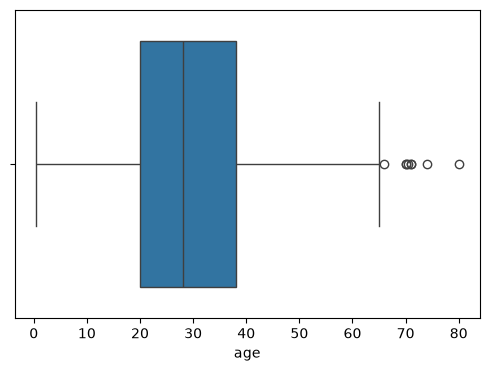

In [5]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x='age')
plt.show()

In [6]:
# Isolons les outliers 

iqr = df['age'].quantile(0.75) - df['age'].quantile(0.25)  #iqr  = Q3 - Q1

df[df['age'] > (df['age'].quantile(0.75) + (1.5 * iqr ))]

# On décide de les garders car les outliers de age ne sont pas abérrant et il y'en a peu

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,Southampton,no,True
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,Cherbourg,no,True
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,Queenstown,no,True
493,0,1,male,71.0,0,0,49.5042,C,First,man,True,Cherbourg,no,True
630,1,1,male,80.0,0,0,30.0000,S,First,man,True,Southampton,yes,True
672,0,2,male,70.0,0,0,10.5000,S,Second,man,True,Southampton,no,True
745,0,1,male,70.0,1,1,71.0000,S,First,man,True,Southampton,no,False
851,0,3,male,74.0,0,0,7.7750,S,Third,man,True,Southampton,no,True


In [7]:
df['age'].mean()
df['age'].median()

np.float64(28.0)

In [8]:
df['age'] = df['age'].fillna(df["age"].mean())

In [9]:
df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Voilà, on vient de gérer les features, ici on a retiré les lignes avec valeurs nulles (age) et la colonne deck.

Passons à l'encodage

In [10]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,29.642093,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


Pour le sexe, on fait un onehotencoder

In [11]:
df["is_male"] = df["sex"].map({"male":1,
                               "female":0})

df = df.drop(columns=["sex"])

df

,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,is_male
0,0,3,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False,1
1,1,1,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,0
2,1,3,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,0
3,1,1,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False,0
4,0,3,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,S,Second,man,True,Southampton,no,True,1
887,1,1,19.000000,0,0,30.0000,S,First,woman,False,Southampton,yes,True,0
888,0,3,29.642093,1,2,23.4500,S,Third,woman,False,Southampton,no,False,0
889,1,1,26.000000,0,0,30.0000,C,First,man,True,Cherbourg,yes,True,1


Je remarque who et adult male sont deux colonne en lien avec le sex 

In [12]:
df = df.drop(columns=["adult_male","who"])
df

,survived,pclass,age,sibsp,parch,fare,embarked,class,embark_town,alive,alone,is_male
0,0,3,22.000000,1,0,7.2500,S,Third,Southampton,no,False,1
1,1,1,38.000000,1,0,71.2833,C,First,Cherbourg,yes,False,0
2,1,3,26.000000,0,0,7.9250,S,Third,Southampton,yes,True,0
3,1,1,35.000000,1,0,53.1000,S,First,Southampton,yes,False,0
4,0,3,35.000000,0,0,8.0500,S,Third,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,S,Second,Southampton,no,True,1
887,1,1,19.000000,0,0,30.0000,S,First,Southampton,yes,True,0
888,0,3,29.642093,1,2,23.4500,S,Third,Southampton,no,False,0
889,1,1,26.000000,0,0,30.0000,C,First,Cherbourg,yes,True,1


Survived et alive ?

est-ce la même chose ?

In [13]:
df['alive'] = df['alive'].map({"no":0,
                               "yes":1})

Ensuite, embarked. => clairement un onehot

In [14]:
df[df['survived'] != df['alive']]

,survived,pclass,age,sibsp,parch,fare,embarked,class,embark_town,alive,alone,is_male


donc on le dégage

In [15]:
df = df.drop(columns=["alive"])

sibsp et parch = frr soeur, conjoint et parch enfant parentes => sont reliés à alone, que fait on ?

In [16]:
df.head()

,survived,pclass,age,sibsp,parch,fare,embarked,class,embark_town,alone,is_male
0,0,3,22.0,1,0,7.2500,S,Third,Southampton,False,1
1,1,1,38.0,1,0,71.2833,C,First,Cherbourg,False,0
2,1,3,26.0,0,0,7.9250,S,Third,Southampton,True,0
3,1,1,35.0,1,0,53.1000,S,First,Southampton,False,0
4,0,3,35.0,0,0,8.0500,S,Third,Southampton,True,1


In [17]:
df = df.drop(columns=['sibsp','parch'])

In [18]:
df = df.drop(columns="embark_town")

Mtn, le oneHotEncoder our embarked et embark_town

In [19]:
df = pd.get_dummies(data=df,columns=['embarked'], drop_first=True) # On drop_first pour retirer une colonne car les deux autres donnes déjà l'info, on veut la retirer pour éviter la redondance dûe à la corrélation
df

,survived,pclass,age,fare,class,alone,is_male,embarked_Q,embarked_S
0,0,3,22.000000,7.2500,Third,False,1,False,True
1,1,1,38.000000,71.2833,First,False,0,False,False
2,1,3,26.000000,7.9250,Third,True,0,False,True
3,1,1,35.000000,53.1000,First,False,0,False,True
4,0,3,35.000000,8.0500,Third,True,1,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,13.0000,Second,True,1,False,True
887,1,1,19.000000,30.0000,First,True,0,False,True
888,0,3,29.642093,23.4500,Third,False,0,False,True
889,1,1,26.000000,30.0000,First,True,1,False,False


Mtn, on s'occupe de class

In [20]:
df['class'] = df['class'].map({"First":2,
                               "Second":1,
                               "Third":0})

In [21]:
df = df.drop(columns=["pclass"])

In [22]:
df.head()

,survived,age,fare,class,alone,is_male,embarked_Q,embarked_S
0,0,22.0,7.2500,0,False,1,False,True
1,1,38.0,71.2833,2,False,0,False,False
2,1,26.0,7.9250,0,True,0,False,True
3,1,35.0,53.1000,2,False,0,False,True
4,0,35.0,8.0500,0,True,1,False,True


Voilà, fin de la préparation de la data, on passe au mining et modeling

Séparons les features de la target

In [23]:
X = df.drop(columns=["survived"])
y = df["survived"]

Maintenant, séparons le train et le test

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train

,age,fare,class,alone,is_male,embarked_Q,embarked_S
708,22.000000,151.5500,2,True,0,False,True
240,29.642093,14.4542,0,False,0,False,False
382,32.000000,7.9250,0,True,1,False,True
792,29.642093,69.5500,0,False,0,False,True
683,14.000000,46.9000,0,False,1,False,True
...,...,...,...,...,...,...,...
107,29.642093,7.7750,0,True,1,False,True
271,25.000000,0.0000,0,True,1,False,True
862,48.000000,25.9292,2,True,0,False,True
436,21.000000,34.3750,0,False,0,False,True


In [25]:
model = DecisionTreeClassifier(criterion='entropy',random_state=42,max_depth=10)  # Comme c'est un arbre de décision, osef de scale mes features car il travaille feature par feature

model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [26]:
model.fit(X_train,y_train)
model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

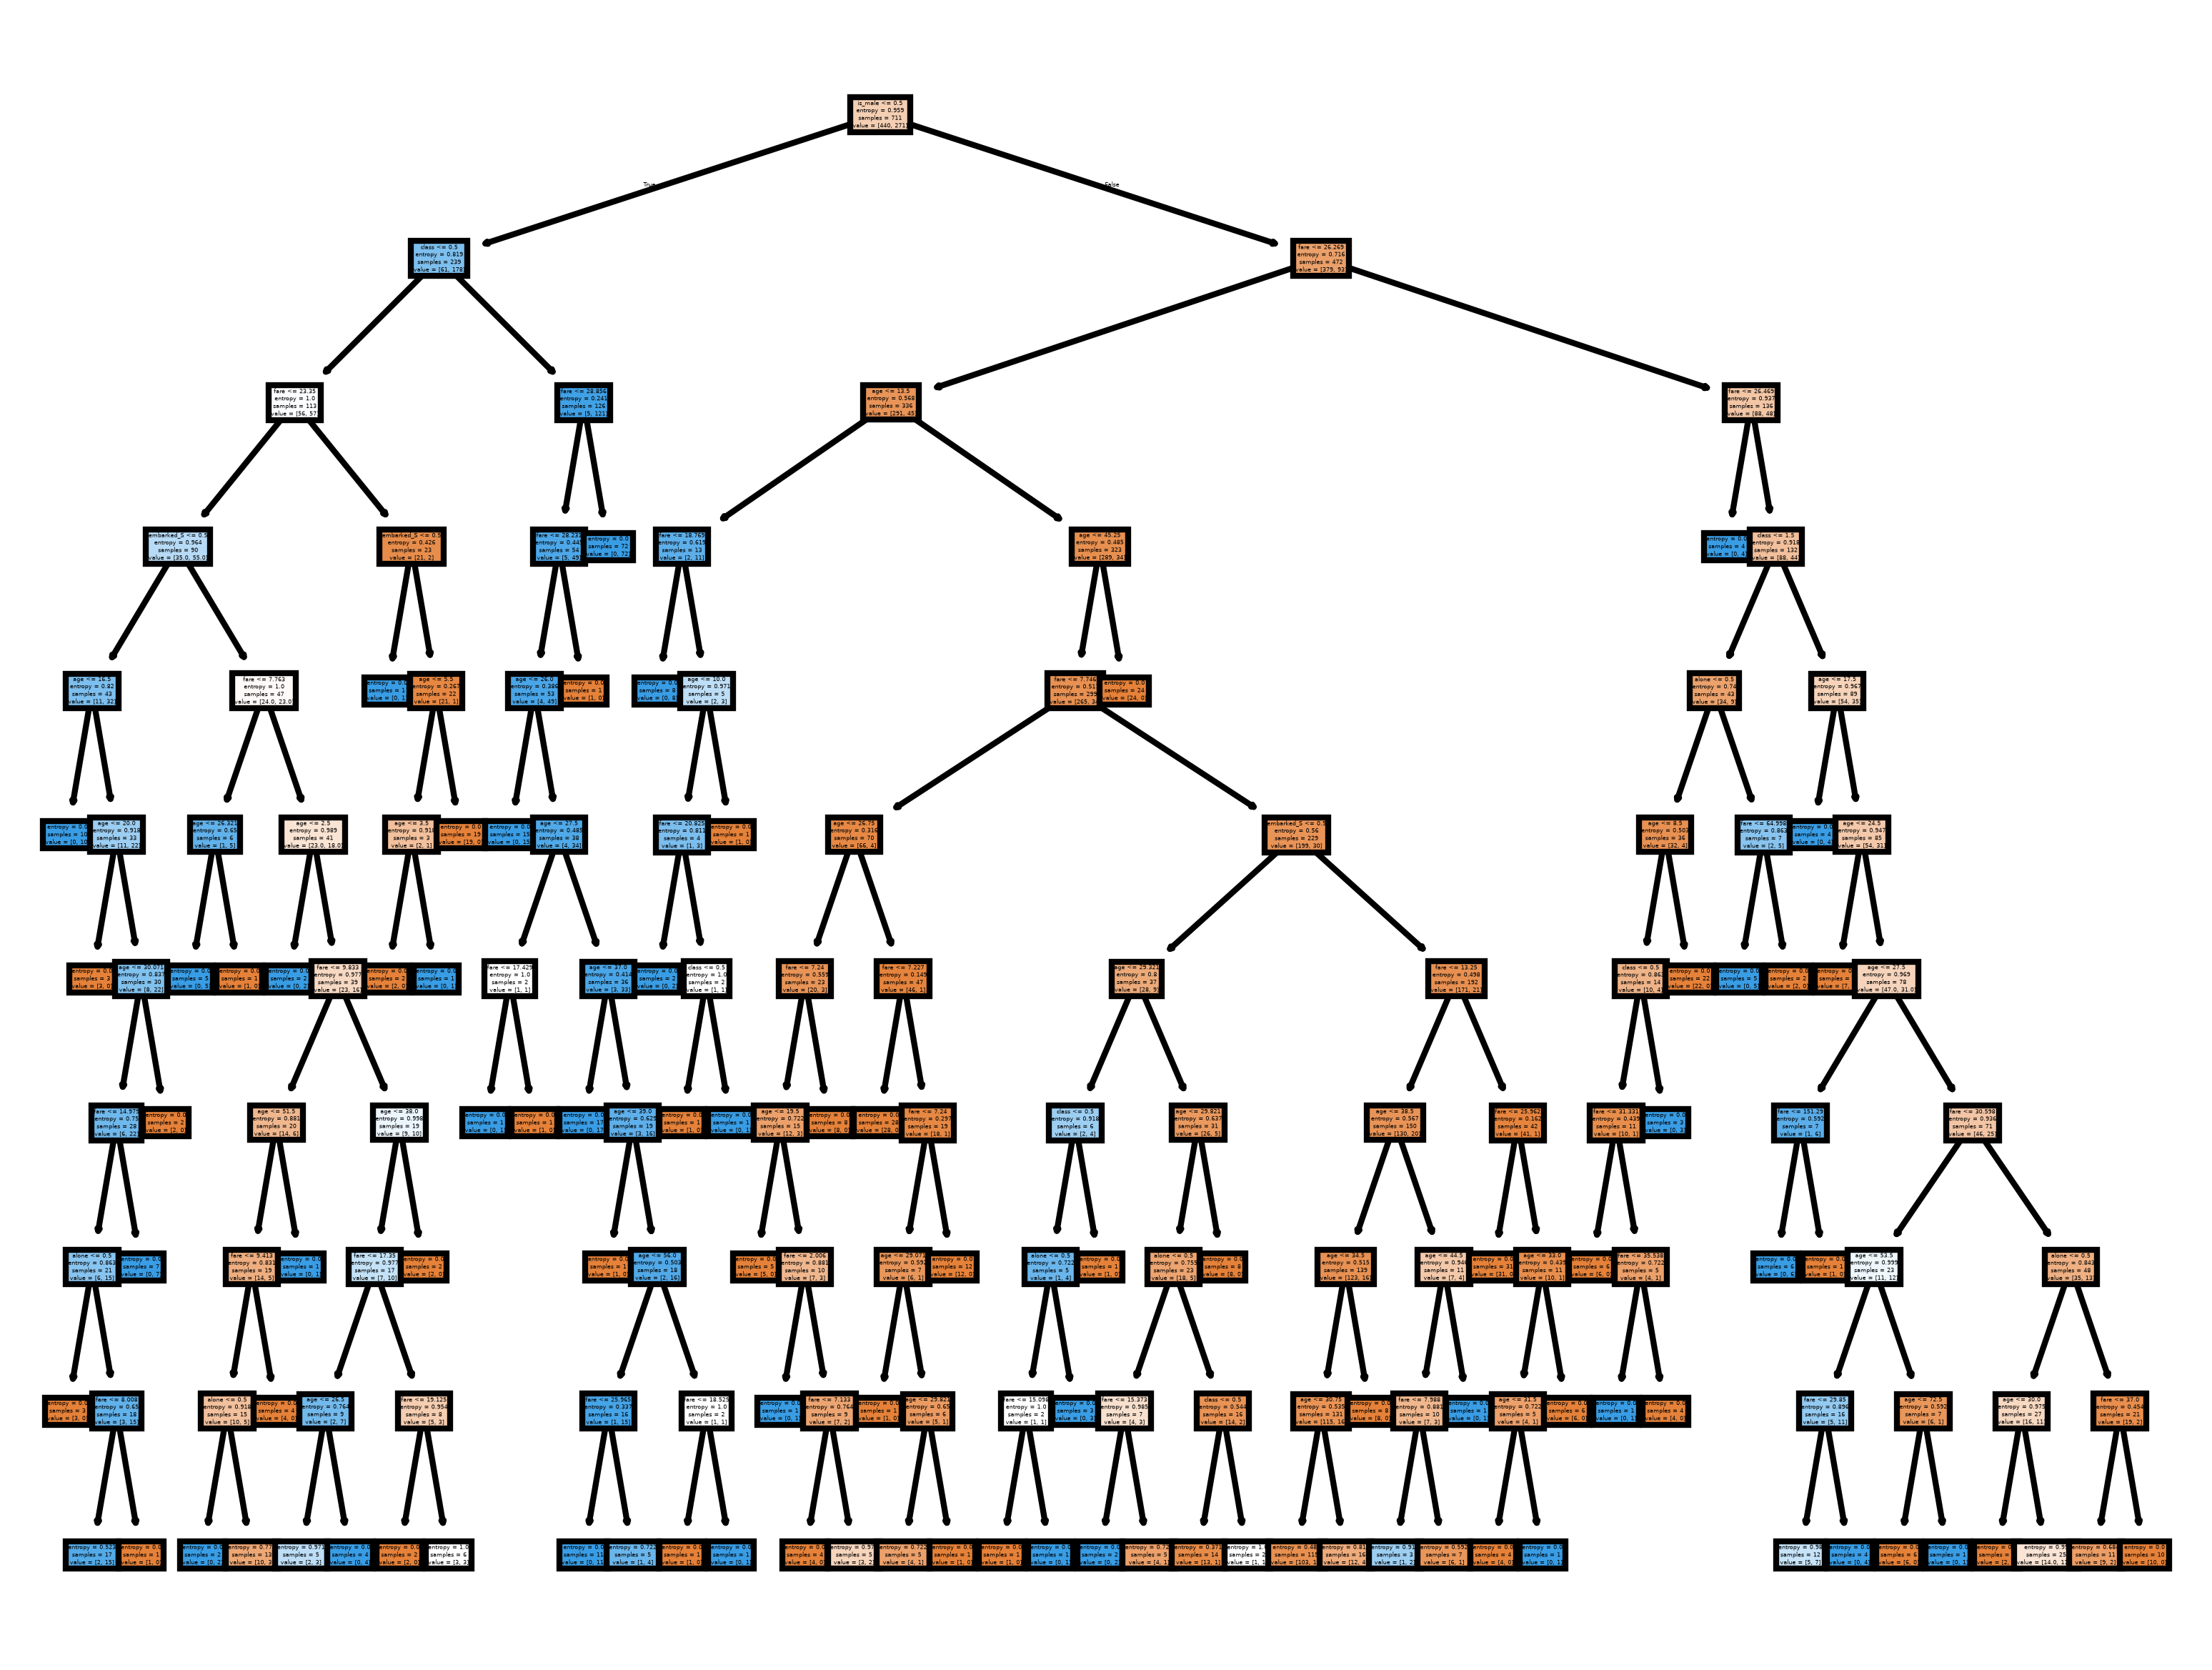

In [27]:
plt.figure(dpi=600) #dpi permet de voir plus clair dans le cas de grand arbres
plot_tree(model, filled=True, feature_names=X_train.columns)
plt.show()

In [28]:
model.max_depth

10

In [29]:
model.feature_importances_  # Renvoi des informations de quelles features ont été importantes et dans quel mesure

array([0.25752541, 0.24469425, 0.13441993, 0.05046427, 0.29035257,
       0.        , 0.02254357])

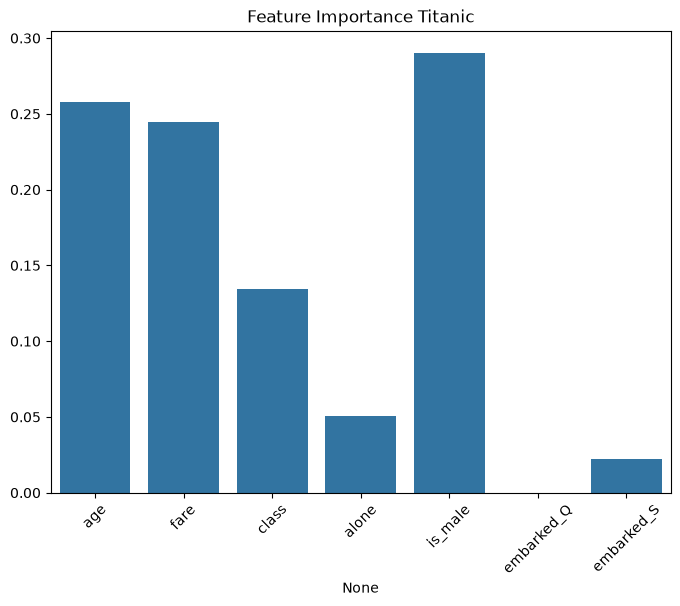

In [30]:
plt.figure(figsize=(8,6))
plt.title("Feature Importance Titanic")
sns.barplot(x=X_train.columns, y=model.feature_importances_)
plt.xticks(rotation=45) # permet d'écarter un peut les batonnets poiur une meilleure visibilité
plt.show()

In [31]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1])

In [32]:
display(accuracy_score(y_test,y_pred))
model.score(X_test,y_test)

0.7808988764044944

0.7808988764044944

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.80      0.82       109
           1       0.70      0.75      0.73        69

    accuracy                           0.78       178
   macro avg       0.77      0.78      0.77       178
weighted avg       0.78      0.78      0.78       178



On veux maximiser la précision quand on veut minimiser les faux positifs (ex. Classification de spam => on préfére éviter le faux positif (préfère avoir un spam dans les mails que un mail dans les spams))
recall => on veux le max quand on veut minimiser les faux négatifs (ex. domaine médical, malade)

Passons à la matrice de confusion

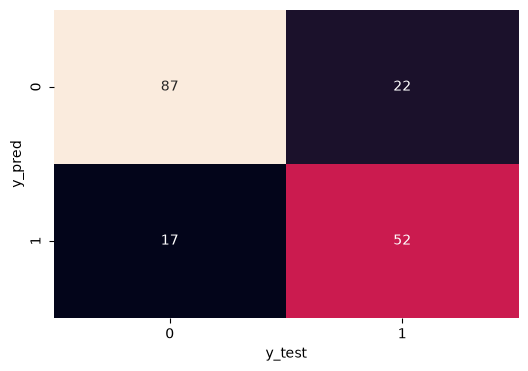

In [34]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,cbar=False)
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.show()

La matrice de confusion voir la ou mon modèle s'est trompés (diagonales, corrects)

le modèle à prédit 87 morts et s'est trompé 17 fois
Sur les vivants, il à 52 bonnes réponses et s'est trompés 22 fois

In [35]:
# show de linspace
np.linspace(0.1,1,10) # => va entrainer 1 fois avec 10% des données, ensuite 20% des données, ... => permet de savoir si on doit aller chercher plus de données pour mon dataset
# Applicaiton dans learning_curve ci dessous

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [36]:
size, train_score,val_score = learning_curve(DecisionTreeClassifier(random_state=42),
                                             X_train,
                                             y_train,
                                             train_sizes=np.linspace(0.1,1,10), # attention train_size n'est pas une valeur scalaire mais un espece linéaire
                                             scoring="accuracy",
                                             cv=5) 

In [37]:
display(size)
display(train_score) 
display(val_score) # => J'ai 10 résultats et je l'ai 5 fois (10 résultats est dû à train_size et le 5 fois du à cross validation (cv)) Donc, j,'ai entrainé 50 modèles
# On pourra donc prendre la moyenne des résultats pour limiter l'impact de l'échantillonage

array([ 56, 113, 170, 227, 284, 340, 397, 454, 511, 568])

array([[1.        , 1.        , 1.        , 1.        , 1.        ],
       [1.        , 0.98230088, 0.98230088, 0.98230088, 0.98230088],
       [1.        , 0.98823529, 0.98823529, 0.98823529, 0.98823529],
       [0.99559471, 0.98678414, 0.99118943, 0.99118943, 0.99118943],
       [0.99295775, 0.98943662, 0.99295775, 0.99295775, 0.99295775],
       [0.98823529, 0.98529412, 0.98823529, 0.99117647, 0.99117647],
       [0.98740554, 0.98488665, 0.98992443, 0.98740554, 0.98740554],
       [0.98678414, 0.9845815 , 0.98898678, 0.98898678, 0.98678414],
       [0.98825832, 0.98630137, 0.99021526, 0.99021526, 0.98630137],
       [0.98943662, 0.98591549, 0.98943662, 0.98943662, 0.98415493]])

array([[0.65034965, 0.77464789, 0.76760563, 0.73239437, 0.71830986],
       [0.67132867, 0.73239437, 0.78873239, 0.76760563, 0.75352113],
       [0.68531469, 0.81690141, 0.78873239, 0.70422535, 0.6971831 ],
       [0.72727273, 0.72535211, 0.78873239, 0.75352113, 0.72535211],
       [0.74125874, 0.74647887, 0.78873239, 0.71126761, 0.70422535],
       [0.75524476, 0.79577465, 0.79577465, 0.72535211, 0.76056338],
       [0.76923077, 0.8028169 , 0.78169014, 0.76056338, 0.77464789],
       [0.73426573, 0.77464789, 0.75352113, 0.79577465, 0.72535211],
       [0.74825175, 0.78169014, 0.73943662, 0.78169014, 0.77464789],
       [0.73426573, 0.79577465, 0.73239437, 0.75352113, 0.8028169 ]])

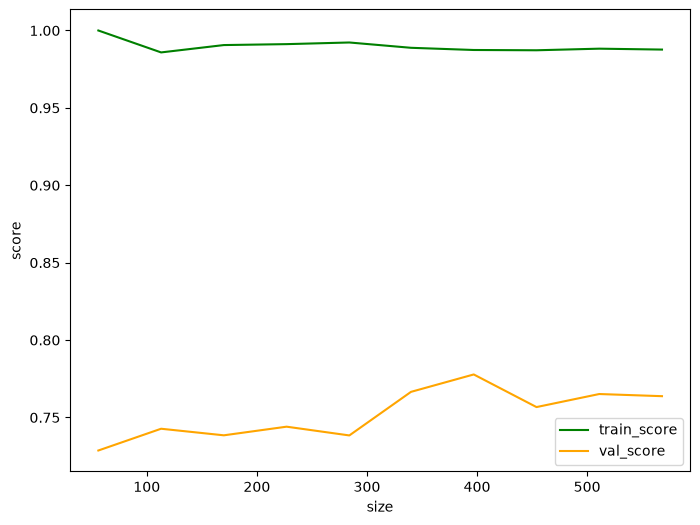

In [38]:
plt.figure(figsize=(8,6))
plt.plot(size,train_score.mean(axis=1),c='green',label='train_score')
plt.plot(size,val_score.mean(axis=1),c='orange',label='val_score')
plt.xlabel("size")
plt.ylabel("score")
plt.legend()
plt.show()

Voilà à quoi ressemble le résultat d'une learning curve

Donne des réponses très importantes :
Est-ce que mon modèle est en overfit ou underfit ? 
overfitting : modèle trop spécialisé sur les données d'entrainement et ne sais plus généraliser la problématique
underfitting : modèle est mauvais à l'entrainement et à la validation


est-ce que plus de données améliorerait mon modèle ? => à priori non car la courbe arrive sur un plat donc on a assez de données

pas d'overfitting ici, l'écart est ok
et pas d'underfiting car le score de train est bon donc il a bien compris

In [39]:
params = {"criterion":['gini','entropy'],
          "max_depth":[5,10,15,25,50]}

Ensuite on va set une grille, en lui donnant tous les paramètres dont elle à besoin

In [40]:
grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid=params,
                    scoring="accuracy",
                    cv=5,
                    n_jobs=-1 #multithreading
                    )
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of infor

In [41]:
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of infor

In [43]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.038061,0.001675,0.004022,0.000752,gini,5,"{'criterion': 'gini', 'max_depth': 5}",0.783217,0.809859,0.802817,0.816901,0.774648,0.797488,0.016023,4
1,0.023721,0.016105,0.002998,0.000188,gini,10,"{'criterion': 'gini', 'max_depth': 10}",0.776224,0.823944,0.788732,0.802817,0.802817,0.798907,0.015972,2
2,0.004421,0.000898,0.002543,0.000063,gini,15,"{'criterion': 'gini', 'max_depth': 15}",0.748252,0.802817,0.739437,0.823944,0.809859,0.784862,0.034288,6
3,0.004177,0.000395,0.002538,0.000058,gini,25,"{'criterion': 'gini', 'max_depth': 25}",0.734266,0.795775,0.753521,0.802817,0.802817,0.777839,0.028494,9
4,0.003974,0.000490,0.002507,0.000091,gini,50,"{'criterion': 'gini', 'max_depth': 50}",0.734266,0.795775,0.753521,0.802817,0.802817,0.777839,0.028494,9
5,0.004088,0.000598,0.002523,0.000132,entropy,5,"{'criterion': 'entropy', 'max_depth': 5}",0.790210,0.816901,0.802817,0.816901,0.795775,0.804521,0.010870,1
6,0.003942,0.000352,0.002717,0.000591,entropy,10,"{'criterion': 'entropy', 'max_depth': 10}",0.790210,0.809859,0.788732,0.788732,0.816901,0.798887,0.012053,3
7,0.004533,0.000560,0.004208,0.001813,entropy,15,"{'criterion': 'entropy', 'max_depth': 15}",0.734266,0.816901,0.774648,0.802817,0.802817,0.786290,0.029412,5
8,0.004794,0.000384,0.002536,0.000081,entropy,25,"{'criterion': 'entropy', 'max_depth': 25}",0.734266,0.809859,0.767606,0.781690,0.802817,0.779248,0.027046,7
9,0.003948,0.000230,0.002518,0.000140,entropy,50,"{'criterion': 'entropy', 'max_depth': 50}",0.734266,0.809859,0.767606,0.781690,0.802817,0.779248,0.027046,7


Voici le résultat de tous les entrainement de la grille 

In [44]:
final_model = grid.best_estimator_

y_pred = final_model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       109
           1       0.78      0.67      0.72        69

    accuracy                           0.80       178
   macro avg       0.79      0.77      0.78       178
weighted avg       0.80      0.80      0.79       178

